# 01 — Perfil e auditoria dos dados
**Projeto:** PI 4CCOMP 2026/2 — CTI Global
**Fase CRISP-DM:** Entender os Dados
**Fonte:** Demonstrativo Fecap v3.csv (CTI Global, recebido em 21/08/2026)

Objetivo: descrever a estrutura do arquivo, explorar seu conteúdo
e verificar a qualidade dos dados antes de qualquer transformação.

In [1]:
import pandas as pd

## Coletar dados iniciais

Primeira tarefa da fase *Entender os Dados* do CRISP-DM: carregar o arquivo bruto
sem alterar nada nele. O arquivo da CTI não segue o padrão que o `read_csv` assume
por default, então cada parâmetro abaixo corrige uma diferença específica.


In [2]:
from pathlib import Path

# O caminho relativo simples quebra porque o Jupyter nem sempre roda a partir
# da pasta do notebook. A solução: subir a partir do diretório atual até achar
# a raiz do repositório (a pasta que contém src/data/raw).
raiz = Path.cwd()
while not (raiz / "src" / "data" / "raw").exists() and raiz != raiz.parent:
    raiz = raiz.parent

CAMINHO = raiz / "src" / "data" / "raw" / "Demonstrativo Fecap v3.csv"
print("lendo de:", CAMINHO)

df = pd.read_csv(
    CAMINHO,
    sep=";",                                     # as colunas são separadas por ponto e vírgula
    header=None,                                 # o arquivo não tem linha de cabeçalho
    names=["ano", "cenario", "conta", "valor"],  # por isso nomeamos as 4 colunas aqui
    encoding="latin-1",                          # sem isso os acentos vêm quebrados
    decimal=",",                                 # no arquivo a vírgula é o separador decimal
    thousands=".",                               # e o ponto é o separador de milhar
)

df.head()

lendo de: C:\Users\Gusta\OneDrive\Documentos\GitHub\Projeto6\src\data\raw\Demonstrativo Fecap v3.csv


,ano,cenario,conta,valor
0,Ano 1,Total Cen_00001,NaN,2.513881e-02
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07


### Conferindo se a leitura funcionou

Três verificações antes de seguir:

1. **1.002.000 linhas e 4 colunas**
2. **`valor` como `float64`** — se vier como texto, a conversão numérica não aconteceu
3. **valores na casa dos bilhões** — se o máximo vier em milhares, o separador de milhar foi lido errado


In [3]:
print("linhas e colunas:", df.shape)
print()
print(df.dtypes)   # 'valor' precisa ser float64; as outras três são texto
print()
print("valor mínimo:", df["valor"].min())
print("valor máximo:", df["valor"].max())

linhas e colunas: (1002000, 4)

ano            str
cenario        str
conta          str
valor      float64
dtype: object

valor mínimo: -15879812955.3528
valor máximo: 15821841345.9487


## Descrever os dados

Segunda tarefa do CRISP-DM. O objetivo aqui é responder *"o que existe dentro
deste arquivo?"* — ainda sem interpretar nada, só levantando a estrutura.


In [4]:
# Quantos valores diferentes existem em cada coluna.
# nunique() ignora valores nulos automaticamente.
print("anos distintos    :", df["ano"].nunique())
print("cenários distintos:", df["cenario"].nunique())
print("contas distintas  :", df["conta"].nunique())

anos distintos    : 12
cenários distintos: 1200
contas distintas  : 69


In [5]:
# Quais são os anos. Ordenamos pelo número, não pelo texto:
# em ordem alfabética "Ano 10" viria antes de "Ano 2".
anos = sorted(df["ano"].unique(), key=lambda a: int(a.split()[1]))
print(anos)

# Os cenários são muitos, então olhamos só os extremos
cenarios = sorted(df["cenario"].unique())
print("\nprimeiro:", cenarios[0], "| último:", cenarios[-1], "| total:", len(cenarios))

['Ano 1', 'Ano 2', 'Ano 3', 'Ano 4', 'Ano 5', 'Ano 6', 'Ano 7', 'Ano 8', 'Ano 9', 'Ano 10', 'Ano 11', 'Ano 12']

primeiro: Total Cen_00001 | último: Total Cen_01200 | total: 1200


In [6]:
# Existem linhas sem nome de conta?
print("linhas com conta vazia:", df["conta"].isna().sum())

# A lista completa das 69 contas
for c in sorted(df["conta"].dropna().unique()):
    print(c)

linhas com conta vazia: 43200
BAL  - Capital Social
BAL  - Dividendos Antecipados
BAL  - Patrimônio Líquido
BAL  - Prov para Contingências
BAL  - Reserva de Retenção de Lucros
BAL  - Reservas Legais
BAL  - Reservas de Capital
BAL  - Resultado Acumulado
BAL  - Resultado do Período
BAL - Amortização - Intangível
BAL - Amortização Acumulada
BAL - At Fiscal Diferido
BAL - Ativo Circulante
BAL - Contas a Pagar - Parte Relacionada
BAL - Contas a Receber - Clientes
BAL - Contas a Receber - Partes Relacionadas
BAL - Contas a Receber - SWAP
BAL - Créditos Tributários
BAL - Depreciação Acumulada
BAL - Diferido
BAL - Disponível
BAL - Emprést
BAL - Empréstimos
BAL - Encargos Sociais e Trabalhistas
BAL - Estoques Diversos
BAL - Exigível a Longo Prazo
BAL - Fornecedores
BAL - Impostos
BAL - Investimentos - Imobilizado
BAL - Investimentos - Intangível
BAL - Obrigações com o Poder Concedente
BAL - Outorga da Concessão
BAL - Outros Créditos
BAL - Outros Créditos LP
BAL - Outros Débitos
BAL - Outros deb

In [7]:
# Quantas linhas há em cada bloco de conta.
# O prefixo é o texto antes do primeiro " - ": split(" - ") quebra o nome
# em pedaços e .str[0] pega o primeiro.
bloco = df["conta"].str.split(" - ").str[0]
print(bloco.value_counts(dropna=False))

# ATENÇÃO ao resultado: um dos blocos aparece DUAS vezes na contagem.
# Isso não é bug do código — é uma inconsistência no arquivo. Investigue por quê.

conta
BAL     468000
DRE     201600
FLU     172800
BAL     116400
NaN      43200
Name: count, dtype: int64


In [8]:
# Resumo estatístico da única coluna numérica
df["valor"].describe()

count    1.002000e+06
mean     4.064611e+08
std      3.460617e+09
min     -1.587981e+10
25%     -5.863950e+08
50%     -2.054438e+05
75%      8.236062e+08
max      1.582184e+10
Name: valor, dtype: float64

### Leitura dos resultados

- O arquivo tem **1.002.000 linhas**, cobrindo **12 anos** de horizonte de projeção
  (`Ano 1` a `Ano 12`, não anos de calendário) e **1.200 cenários** simulados.
- As contas se dividem em três blocos: **`BAL`** (balanço patrimonial, 43 contas),
  **`DRE`** (demonstração do resultado, 14 contas) e **`FLU`** (fluxo de caixa, 12 contas).
  Juntos, formam as três demonstrações financeiras completas de uma concessionária.
- Existem **43.200 linhas sem nome de conta** — exatamente 3 por par ano×cenário.
- O bloco `BAL` aparece **duas vezes** na contagem porque parte das contas usa
  `"BAL - "` e parte usa `"BAL  - "`, com **dois espaços**. Como a separação é feita
  pelo texto `" - "`, o espaço extra sobra grudado no prefixo e cria um segundo grupo.
  É uma inconsistência de digitação no arquivo de origem, não um bloco novo.
- O `describe()` mostra valores negativos e positivos porque o arquivo mistura naturezas
  contábeis diferentes na mesma coluna: contas de ativo e receita são positivas, e contas
  de passivo, custo e saída de caixa aparecem com sinal negativo.


## Explorar os dados e verificar a qualidade

Terceira e quarta tarefas do CRISP-DM.

**Descrever** é perguntar ao dado o que ele é. **Verificar a qualidade** é o contrário:
afirmar primeiro o que *deveria* ser verdade e testar. Onde a afirmação falha, existe
um achado — e achado é o que vira frase de relatório.

Cada bloco abaixo declara a expectativa antes de testá-la.


### Item 1 — cada ano tem as mesmas contas?

**Expectativa:** os 12 anos deveriam trazer as mesmas 69 contas.

**Como o código funciona:** `groupby("ano")` separa as linhas em 12 grupos, um por ano.
`["conta"].nunique()` conta quantos nomes *diferentes* de conta existem dentro de cada
grupo. O `reindex` só reordena o resultado — sem ele, a ordem seria alfabética e
`Ano 10` apareceria antes de `Ano 2`.


In [9]:
# Ordem numérica dos anos (e não alfabética)
ordem_anos = sorted(df["ano"].unique(), key=lambda a: int(a.split()[1]))

contas_por_ano = df.groupby("ano")["conta"].nunique().reindex(ordem_anos)
print(contas_por_ano.to_string())

ano
Ano 1     68
Ano 2     68
Ano 3     69
Ano 4     69
Ano 5     69
Ano 6     69
Ano 7     69
Ano 8     69
Ano 9     69
Ano 10    69
Ano 11    69
Ano 12    42


### Item 4 — todo par (ano, cenário) tem o mesmo número de linhas?

**Expectativa:** cada combinação de ano e cenário deveria ter a mesma quantidade de linhas.

**Como funciona:** `groupby(["ano", "cenario"])` cria um grupo para cada combinação —
12 anos × 1.200 cenários = 14.400 grupos. `.count()` conta as linhas com conta preenchida
em cada um. Em vez de olhar 14.400 números, `value_counts()` resume: quantos grupos têm
cada tamanho.


In [10]:
contagem = df.groupby(["ano", "cenario"])["conta"].count()

print("total de grupos (ano x cenário):", len(contagem))
print()
print("quantos grupos têm cada quantidade de contas:")
print(contagem.value_counts().sort_index().to_string())

total de grupos (ano x cenário): 14400

quantos grupos têm cada quantidade de contas:
conta
42     1200
68     2400
69    10800


### Item 5 — existe (ano, cenário, conta) repetido?

**Expectativa:** essas três colunas juntas deveriam identificar uma linha única.
Se repetem, ou o dado está duplicado ou a chave não é essa.

**Como funciona:** `duplicated(subset=[...])` marca `True` nas repetições, deixando a
primeira ocorrência de fora. Com `keep=False` ele marca *todas* as ocorrências, o que
serve para investigar quem são elas.


In [11]:
n_dup = df.duplicated(subset=["ano", "cenario", "conta"]).sum()
print("linhas duplicadas:", n_dup)

# Quem são essas linhas? keep=False marca todas as ocorrências envolvidas
todas = df.duplicated(subset=["ano", "cenario", "conta"], keep=False)
print("linhas envolvidas:", int(todas.sum()))
print("dessas, com conta vazia:", int(df.loc[todas, "conta"].isna().sum()))

linhas duplicadas: 28800


linhas envolvidas: 43200
dessas, com conta vazia: 43200


### Preparando o terreno: a tabela cruzada

Os itens 6 e 7 comparam contas **entre si** — e hoje cada conta está numa linha
diferente. Para somar ou subtrair uma conta da outra, elas precisam virar **colunas**.

É isso que o `pivot_table` faz:

- `index=["cenario", "ano"]` → cada linha do resultado é uma combinação cenário + ano
- `columns="conta"` → cada conta vira uma coluna
- `values="valor"` → o que preenche as células
- `aggfunc="sum"` → o que fazer se cair mais de um valor na mesma célula

O resultado tem 14.400 linhas e 69 colunas. Antes disso, tiramos as linhas sem nome
de conta, que não representam conta nenhuma.


In [12]:
nomeadas = df[df["conta"].notna()]

p = nomeadas.pivot_table(
    index=["cenario", "ano"],
    columns="conta",
    values="valor",
    aggfunc="sum",
)

print("formato da tabela cruzada:", p.shape)
p.head(3)

formato da tabela cruzada: (14400, 69)


conta                   BAL  - Capital Social  BAL  - Dividendos Antecipados  \
cenario         ano                                                            
Total Cen_00001 Ano 1            -309618939.0                            NaN   
                Ano 10           -309618939.0                   3.809077e+09   
                Ano 11           -309618939.0                   4.266935e+09   

conta                   BAL  - Patrimônio Líquido  \
cenario         ano                                 
Total Cen_00001 Ano 1               -2.014435e+09   
                Ano 10              -3.102773e+09   
                Ano 11              -3.646419e+09   

conta                   BAL  - Prov para Contingências  \
cenario         ano                                      
Total Cen_00001 Ano 1                    -3.850246e+07   
                Ano 10                   -3.850246e+07   
                Ano 11                   -3.850246e+07   

conta                   BAL  - Reserva de Retenção de Lucros  \
cenario         ano                                            
Total Cen_00001 Ano 1                          -3.143802e+09   
                Ano 10                         -3.301030e+09   
                Ano 11                         -3.518320e+09   

conta                   BAL  - Reservas Legais  BAL  - Reservas de Capital  \
cenario         ano                                                          
Total Cen_00001 Ano 1              -61923787.8              -205443.791637   
                Ano 10             -61923787.8              -205443.791637   
                Ano 11             -61923787.8              -205443.791637   

conta                   BAL  - Resultado Acumulado  \
cenario         ano                                  
Total Cen_00001 Ano 1                 1.512632e+09   
                Ano 10                1.512632e+09   
                Ano 11                1.512632e+09   

conta                   BAL  - Resultado do Período  \
cenario         ano                                   
Total Cen_00001 Ano 1                 -1.151661e+07   
                Ano 10                -4.751703e+09   
                Ano 11                -5.535917e+09   

conta                   BAL - Amortização - Intangível  ...  \
cenario         ano                                     ...   
Total Cen_00001 Ano 1                    -5.047124e+09  ...   
                Ano 10                   -1.200028e+10  ...   
                Ano 11                   -1.284384e+10  ...   

conta                   FLU - Distribuição para Acionista  FLU - Entradas  \
cenario         ano                                                         
Total Cen_00001 Ano 1                       -1.532408e+09    9.162700e+07   
                Ano 10                      -3.798612e+09    1.991762e+08   
                Ano 11                      -4.256470e+09    2.264838e+08   

conta                   FLU - Geração de Caixa  \
cenario         ano                              
Total Cen_00001 Ano 1             4.306498e+08   
                Ano 10            4.020450e+08   
                Ano 11            9.204318e+08   

conta                   FLU - Imposto de Renda e Contribuição Social  \
cenario         ano                                                    
Total Cen_00001 Ano 1                                  -9.344728e+08   
                Ano 10                                 -2.101016e+09   
                Ano 11                                 -2.621085e+09   

conta                   FLU - Investimentos  FLU - Receita  \
cenario         ano                                          
Total Cen_00001 Ano 1         -5.340012e+08   5.396831e+09   
                Ano 10        -5.410245e+07   9.313009e+09   
                Ano 11        -4.267875e+07   9.918856e+09   

conta                   FLU - Resultado Financeiro  FLU - Saldo Final  \
cenario         ano                                                     
Total Cen_00

### Item 6 — o balanço fecha?

**Expectativa:** em contabilidade, `Total do Ativo` tem que ser igual a `Total do Passivo`.
É a identidade fundamental do balanço patrimonial.

**Como funciona:** com as contas em colunas, basta subtrair uma da outra. Comparar números
decimais com `==` é arriscado, então usamos uma tolerância: consideramos que "fecha" quando
a diferença absoluta é menor que um centavo.


In [13]:
dif_balanco = p["BAL - Total do Ativo"] - p["BAL - Total do Passivo"]

print("grupos comparáveis :", int(dif_balanco.notna().sum()))
print("grupos que fecham  :", int((dif_balanco.abs() < 0.01).sum()))
print()
print("diferença média : R$ {:,.2f}".format(dif_balanco.mean()))
print("diferença máxima: R$ {:,.2f}".format(dif_balanco.abs().max()))

grupos comparáveis : 14400
grupos que fecham  : 0

diferença média : R$ 15,258,354,333.58
diferença máxima: R$ 23,906,918,054.04


### Item 7 — o fluxo de caixa fecha?

**Expectativa:** `Saldo Final` = `Saldo Inicial` + `Geração de Caixa`.
O saldo que sobra é o que havia mais o que foi gerado no período.


In [14]:
dif_fluxo = p["FLU - Saldo Final"] - (
    p["FLU - Saldo Inicial"] + p["FLU - Geração de Caixa"]
)

print("grupos comparáveis :", int(dif_fluxo.notna().sum()))
print("grupos que fecham  :", int((dif_fluxo.abs() < 0.01).sum()))
print("maior diferença    :", dif_fluxo.abs().max())

grupos comparáveis : 14400
grupos que fecham  : 14400
maior diferença    : 2.002716064453125e-05


### Explorar — como a receita evolui no horizonte

Até aqui olhamos estrutura. Agora olhamos **comportamento**.

A pergunta: a receita cresce ao longo dos 12 anos? E quanto os cenários discordam
entre si sobre esse valor?

**Escolha do gráfico:** linha para a tendência (o eixo X é tempo, e linha é o que mostra
evolução), com uma faixa sombreada entre o P10 e o P90 para representar a incerteza.
A linha central é a **mediana**, não a média — mediana não é distorcida por cenários extremos.


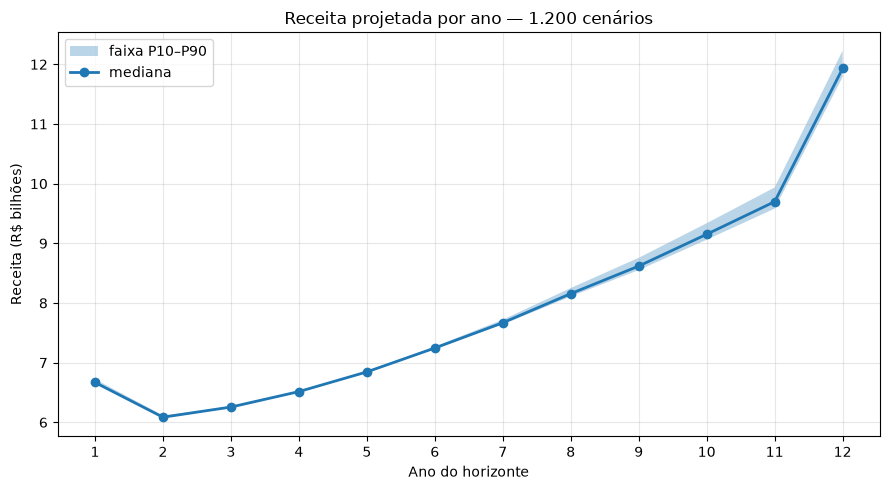

          p10  mediana     p90
ano_n                         
1       6.657    6.669   6.723
2       6.070    6.086   6.115
3       6.245    6.256   6.260
4       6.505    6.515   6.519
5       6.841    6.845   6.849
6       7.234    7.245   7.271
7       7.640    7.669   7.720
8       8.109    8.156   8.251
9       8.551    8.619   8.758
10      9.060    9.152   9.337
11      9.581    9.698   9.936
12     11.787   11.930  12.228


In [15]:
import matplotlib.pyplot as plt

# Extrai o número do ano para poder ordenar e usar no eixo X
df["ano_n"] = df["ano"].str.split().str[1].astype(int)

# Para cada ano, resume os 1.200 cenários em três números
receita = df[df["conta"] == "DRE - Receita"]
faixa = receita.groupby("ano_n")["valor"].agg(
    p10=lambda s: s.quantile(0.10),
    mediana="median",
    p90=lambda s: s.quantile(0.90),
) / 1e9   # converte para bilhões, para o eixo ficar legível

PASTA_IMG = raiz / "imagens"
PASTA_IMG.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(faixa.index, faixa["p10"], faixa["p90"], alpha=0.30, label="faixa P10–P90")
ax.plot(faixa.index, faixa["mediana"], marker="o", linewidth=2, label="mediana")
ax.set_title("Receita projetada por ano — 1.200 cenários")
ax.set_xlabel("Ano do horizonte")
ax.set_ylabel("Receita (R$ bilhões)")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_IMG / "01_receita_por_ano.png", dpi=150)
plt.show()

print(faixa.round(3).to_string())

**O que o gráfico mostra:**

1. A receita **cai** do Ano 1 para o Ano 2 e depois cresce de forma sustentada até o Ano 11.
2. Do Ano 11 para o Ano 12 há um **salto de cerca de 23%** — muito acima do crescimento
   dos anos anteriores. Combinado com o fato de o Ano 12 ter só 42 contas e a taxa sem nome
   ficar negativa nele, isso sugere que **o Ano 12 é o ano de encerramento da concessão**,
   e não um ano de operação normal. É uma hipótese a confirmar com a CTI.
3. A faixa P10–P90 é **muito estreita** — a dispersão vai de 0,5% no Ano 1 a 2,9% no Ano 11.
   Ou seja: os 1.200 cenários praticamente **não discordam sobre a receita**. O que a
   simulação faz variar está em outro lugar (caixa), não no faturamento.
4. A faixa **alarga com o tempo**, o que é o comportamento esperado: incerteza se acumula
   conforme a projeção se distancia do presente.


### Explorar — como o resultado se distribui entre os cenários

Segunda pergunta: fixando um ano, quanto os 1.200 cenários discordam sobre o lucro?

**Escolha do gráfico:** histograma. Ele responde "quantos cenários caem em cada faixa de
valor", que é exatamente a pergunta. As linhas verticais marcam P10, mediana e P90 — os
mesmos números que vão virar KPI no dashboard.


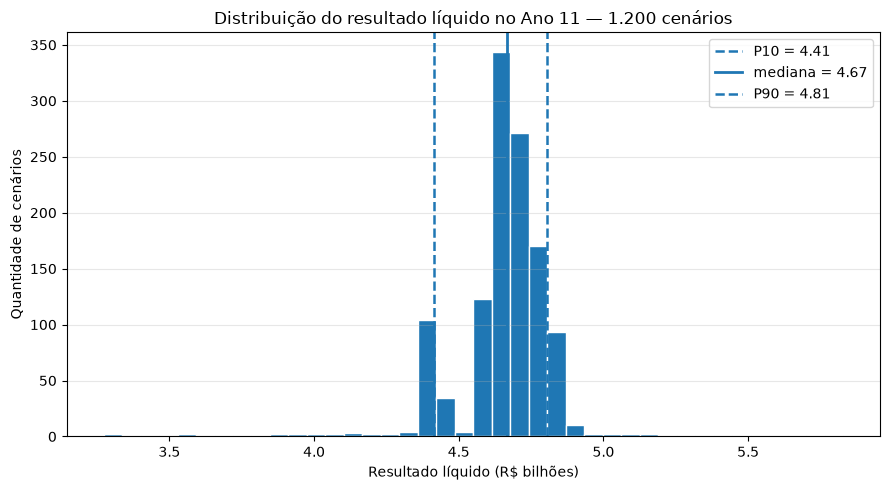

mínimo : 3.273
máximo : 5.828
cenários com prejuízo: 0 de 1200
valores distintos    : 1105 de 1200

valor mais repetido:
valor
4.4135    96


In [16]:
ANO = 11
resultado = df[
    (df["conta"] == "DRE - Resultado Líquido") & (df["ano_n"] == ANO)
]["valor"] / 1e9

p10, p50, p90 = resultado.quantile(0.10), resultado.median(), resultado.quantile(0.90)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(resultado, bins=40, edgecolor="white")
ax.axvline(p10, linestyle="--", linewidth=1.8, label=f"P10 = {p10:.2f}")
ax.axvline(p50, linestyle="-",  linewidth=2.0, label=f"mediana = {p50:.2f}")
ax.axvline(p90, linestyle="--", linewidth=1.8, label=f"P90 = {p90:.2f}")
ax.set_title(f"Distribuição do resultado líquido no Ano {ANO} — 1.200 cenários")
ax.set_xlabel("Resultado líquido (R$ bilhões)")
ax.set_ylabel("Quantidade de cenários")
ax.grid(alpha=0.3, axis="y")
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_IMG / "02_distribuicao_resultado_ano11.png", dpi=150)
plt.show()

print(f"mínimo : {resultado.min():.3f}")
print(f"máximo : {resultado.max():.3f}")
print(f"cenários com prejuízo: {(resultado < 0).sum()} de {len(resultado)}")
print(f"valores distintos    : {resultado.nunique()} de {len(resultado)}")
print("\nvalor mais repetido:")
print(resultado.round(4).value_counts().head(1).to_string())

**O que o gráfico mostra:**

1. A distribuição é **concentrada**: quase tudo entre R$ 4,4 bi e R$ 4,9 bi, com mediana
   em R$ 4,67 bi. A diferença entre P10 e P90 é de apenas R$ 0,39 bi — cerca de 8% da mediana.
2. **Nenhum dos 1.200 cenários dá prejuízo.** Nem o pior caso (R$ 3,27 bi).
3. Há um **acúmulo anormal**: 96 cenários — 8% do total — terminam com exatamente o mesmo
   valor, R$ 4,4135 bi. Em uma simulação contínua isso não deveria acontecer. Sugere um
   **piso no modelo**: alguma regra que trava o resultado quando ele tentaria cair abaixo
   desse ponto. É por isso que P5 e P10 dão o mesmo número.
4. A distribuição não é suave — há um vão entre R$ 4,45 e R$ 4,55 bi, o que reforça a
   hipótese de que o modelo tem regras discretas, e não apenas variação aleatória contínua.

**Consequência para o projeto:** o risco desta concessão, do jeito que o modelo foi
construído, não é risco de prejuízo — é risco de *quanto* lucro. Isso muda o discurso do
painel: em vez de "qual a chance de dar errado", a pergunta útil vira "qual a faixa provável
e o que explica a diferença entre um cenário bom e um ruim".


## Achados consolidados — fase Entender os Dados

| # | Expectativa | Resultado | Impacto |
|---|---|---|---|
| 1 | Todo ano tem 69 contas | Anos 1 e 2 têm 68; **Ano 12 tem 42** | Contas de detalhe somem no último ano |
| 2 | — | Receita salta 23% no Ano 12 | Reforça a hipótese de ano de encerramento |
| 3 | Todo par ano×cenário tem o mesmo tamanho | Três tamanhos: 42, 68 e 69 | Confirma que o padrão vale para os 1.200 cenários |
| 4 | (ano, cenário, conta) é chave única | 28.800 duplicatas | **Todas** vêm das linhas sem nome de conta |
| 5 | Ativo = Passivo | **Não fecha em nenhum grupo** | Diferença média de R$ 15,2 bi — perguntar à CTI |
| 6 | Saldo Final = Inicial + Geração | **Fecha nos 14.400 grupos** | Vira a regra de validação oficial dos KPIs |
| 7 | Simulação produz variação contínua | 96 cenários com valor idêntico | Indica piso no modelo |
| 8 | — | Receita quase não varia entre cenários (CV < 3%) | O risco simulado está no caixa, não no faturamento |

Sobre o Ano 12: ele não perde o balanço inteiro. Mantém 16 contas `BAL`, incluindo
`Total do Ativo` e `Total do Passivo`, e perde 27 contas de detalhe — entre elas todo o
Patrimônio Líquido. Por isso os itens 5 e 6 conseguiram comparar os 14.400 grupos.

### Perguntas geradas por esta fase, para levar à CTI

1. Por que `Total do Ativo` não bate com `Total do Passivo`?
2. O Ano 12 é o encerramento da concessão? O salto de receita é indenização?
3. As três linhas sem nome de conta — a primeira é a taxa de desconto do modelo?
4. Existe um piso no modelo que explica os 96 cenários com resultado idêntico?
5. A simulação contempla cenário de prejuízo, ou só variações favoráveis?

### Próxima fase

**Preparação dos Dados** (CRISP-DM): selecionar, limpar, uniformizar, derivar, integrar e
formatar — produzindo a base analítica em `src/data/processed/`.
